# Fluid flow past a 2D cylinder: Data generation

In this notebook, we visualize and prepare a dataset of fluid flow past a 2D cylinder at Reynolds number $\mathrm{Re} = 2 \cdot 10^3$.
The dataset is obtained by solving the Navier-Stokes equations using the immersed boundary projection method on a grid of about $3 \cdot 10^5$ spatial points, i.e. a state of dimension $6 \cdot 10^5$ for the two velocity components.
Using reduced order modeling, we can obtain a low-dimensional surrogate to this high-dimensional system.
We do so with the proper orthogonal decomposition (POD); by retaining the top $K = 38$ POD modes, we capture 90% of the kinetic energy in the system. 

The dataset is obtained from

``
Course, K. and Nair, P. State estimation of a physical system with unknown governing equations. Nature, 2023.
``

## Imports

In [ ]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt
fontsize = 12

from cylinder_utils import add_colorbar, decode_velocity, plot_field

%matplotlib inline

## Loading the dataset

First, we load the dataset. The dataset is large, so this can take some time.

In [2]:
DATA_DIR = None # NOTE: set to the directory containing vortex.pkl

with open(f"{DATA_DIR}/vortex.pkl", "rb") as f:
    raw = pickle.load(f)

print("Keys:", list(raw.keys()))
print("var_names:", raw["var_names"])
print("x shape:", raw["x"].shape)

Keys: ['x', 'var_names', 'plt_file_list']
var_names: ['x', 'y', 'u', 'v', 'Vorticity']
x shape: (3051, 298301, 5)


In [3]:
var_names = list(raw["var_names"])
print(f"Variables: {var_names}")
print(f"Data shape: {raw['x'].shape}")

n_frames = raw["x"].shape[0]
n_spatial = raw["x"].shape[1]

# Infer grid shape from spatial coordinates
x_raw = raw["x"][0, :, var_names.index("x")]
y_raw = raw["x"][0, :, var_names.index("y")]
n_y = len(np.unique(y_raw))
n_x = n_spatial // n_y
grid_shape = (n_y, n_x)
print(f"Inferred grid shape: {grid_shape} ({n_y} x {n_x} = {n_y * n_x})")
print(f"Full state dim (2 velocity components): {2 * n_y * n_x}")

def get_field(name):
    idx = var_names.index(name)
    field = raw["x"][..., idx]
    return field.reshape(n_frames, *grid_shape)

u = get_field("u") # horizontal velocity
v = get_field("v") # vertical velocity
vort = get_field("Vorticity")

# Spatial coordinates (same for all frames, take first)
x_coord = get_field("x")[0]
y_coord = get_field("y")[0]

del raw # free ~36 GB

print(f"Frames: {n_frames}, grid: {grid_shape}")
print(f"u range: [{u.min():.3f}, {u.max():.3f}]")
print(f"v range: [{v.min():.3f}, {v.max():.3f}]")

Variables: ['x', 'y', 'u', 'v', 'Vorticity']
Data shape: (3051, 298301, 5)
Inferred grid shape: (199, 1499) (199 x 1499 = 298301)
Full state dim (2 velocity components): 596602
Frames: 3051, grid: (199, 1499)
u range: [-1.130, 1.990]
v range: [-1.377, 1.365]


## Visualization

Next, we visualize a few snapshots of the vorticity and velocity fields.

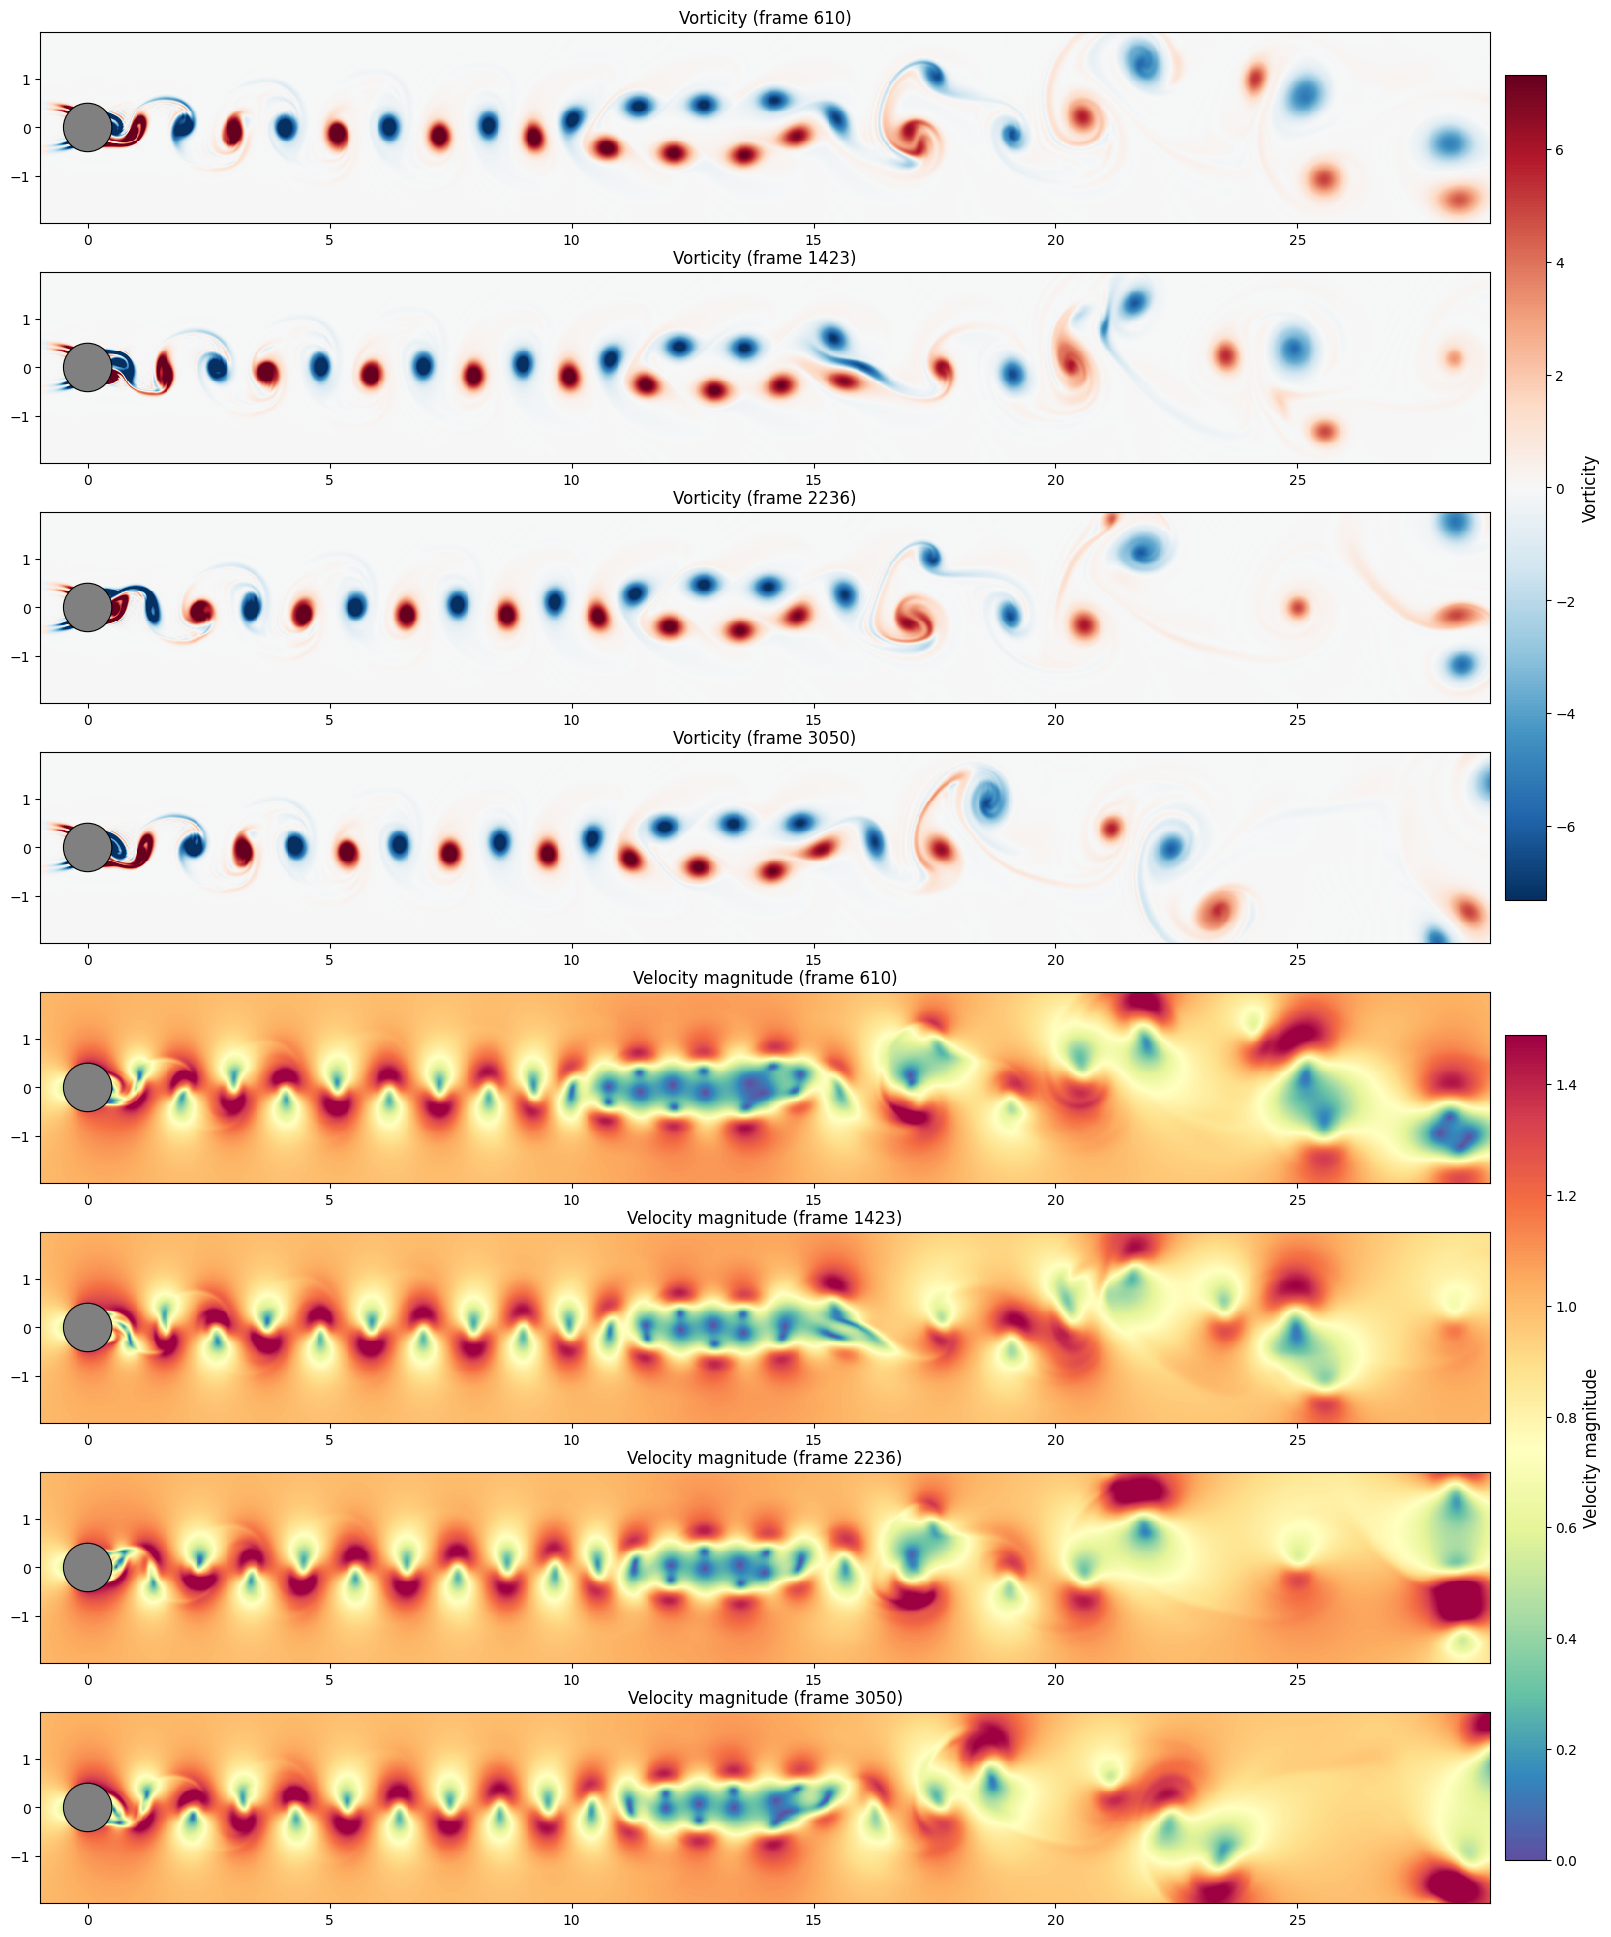

In [4]:
# Pick a few frames spread across the time series
skip = int(0.2 * n_frames) # skip transients (first 20%)
frame_indices = np.linspace(skip, n_frames - 1, 4, dtype=int)

# Shared color limits over the selected frames
vort_max = np.percentile(np.abs(vort[frame_indices]), 99)
vel_mags = np.sqrt(u[frame_indices] ** 2 + v[frame_indices] ** 2)
vel_max = np.percentile(vel_mags, 99)

# One full-width panel per frame, grouped by quantity, with one colorbar per group
n_show = len(frame_indices)
fig, axes = plt.subplots(2 * n_show, 1, figsize=(16, 4.8 * n_show), constrained_layout=True)
for j, idx in enumerate(frame_indices):
    im_vort = plot_field(vort[idx], x_coord, y_coord, axes[j], cmap="RdBu_r", vmin=-vort_max, vmax=vort_max, title=f"Vorticity (frame {idx})", fontsize=fontsize)
    im_vel = plot_field(vel_mags[j], x_coord, y_coord, axes[n_show + j], vmin=0, vmax=vel_max, title=f"Velocity magnitude (frame {idx})", fontsize=fontsize)
add_colorbar(fig, im_vort, axes[:n_show], "Vorticity", fontsize)
add_colorbar(fig, im_vel, axes[n_show:], "Velocity magnitude", fontsize)
plt.show()

We can also add streamlines to visualize direction.

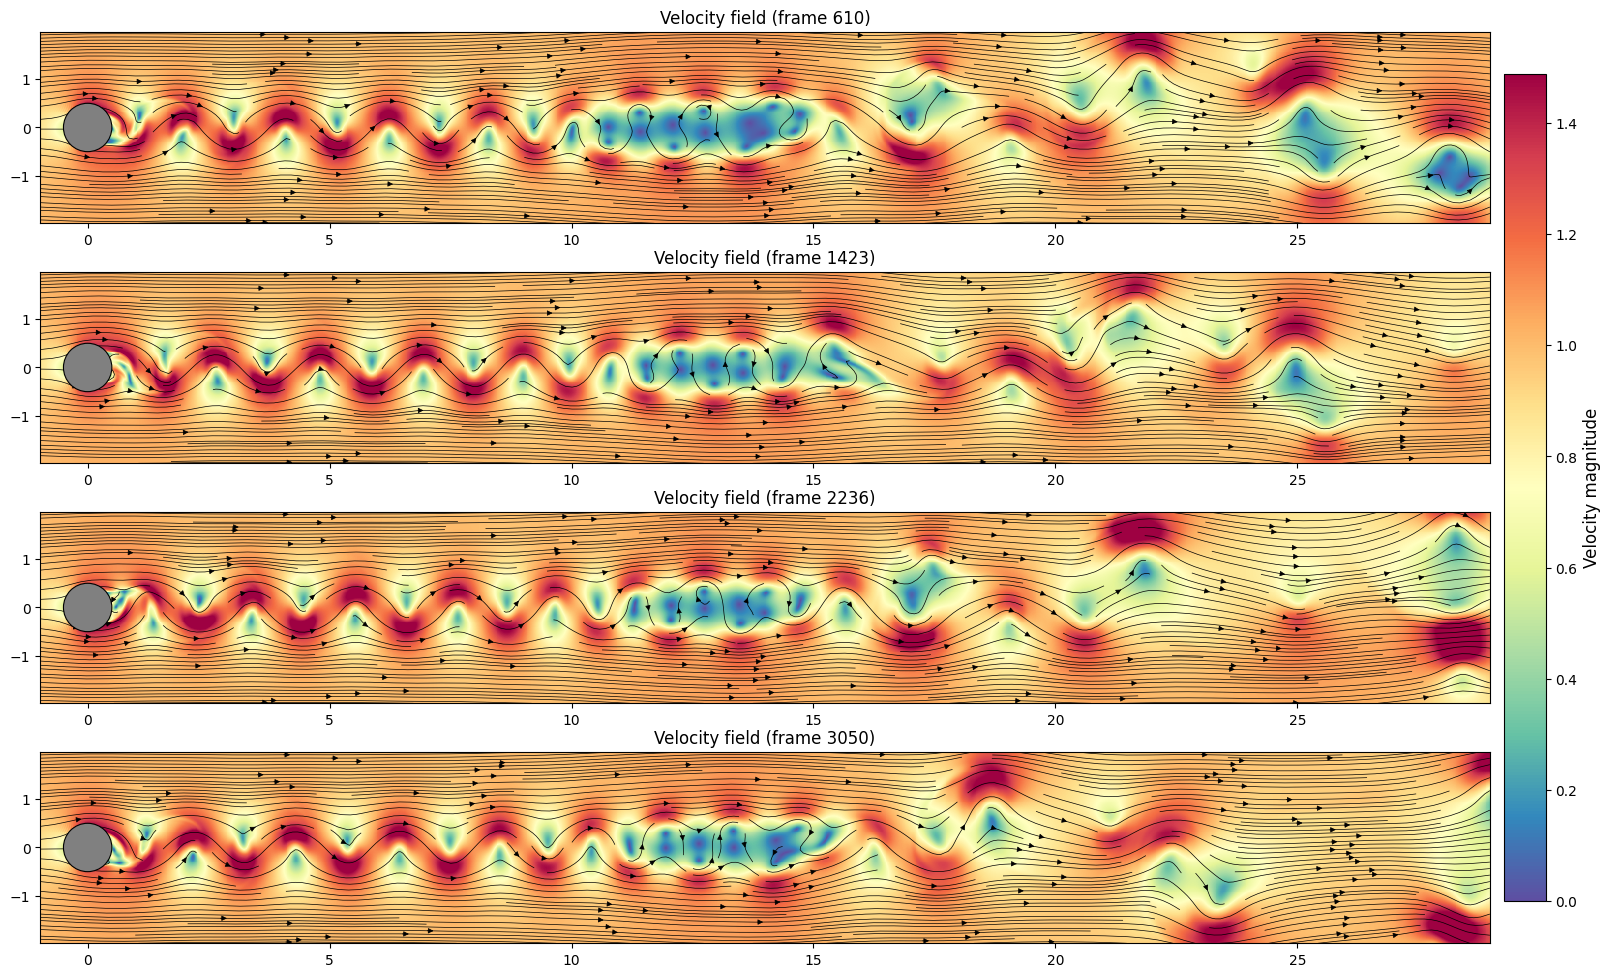

In [5]:
fig, axes = plt.subplots(n_show, 1, figsize=(16, 2.4 * n_show), constrained_layout=True)
for j, idx in enumerate(frame_indices):
    im = plot_field(vel_mags[j], x_coord, y_coord, axes[j], u=u[idx], v=v[idx], vmin=0, vmax=vel_max, title=f"Velocity field (frame {idx})", fontsize=fontsize)
add_colorbar(fig, im, axes, "Velocity magnitude", fontsize)
plt.show()

## Dimensionality reduction via POD

Next, we form a low-dimensional approximation to the spatial discretization of the velocity field via the proper orthogonal decomposition (POD).

In [6]:
import gc
from sklearn.decomposition import PCA

# Stack velocity components as float32: state = [u_flat; v_flat]
u_flat = u.reshape(n_frames, -1).astype(np.float32)
v_flat = v.reshape(n_frames, -1).astype(np.float32)
state = np.concatenate([u_flat, v_flat], axis=1)
del u_flat, v_flat
gc.collect()
print(f"State matrix shape: {state.shape}, dtype: {state.dtype}")

# Skip first 20% (transients), keep the rest
skip_n = int(0.2 * n_frames)
state_post = state[skip_n:].copy()
del state
gc.collect()
n_post = state_post.shape[0]
print(f"Post-transient frames: {n_post}")

# 80/20 train/test split
DT_PHYSICAL = 0.1
t_all = 61.0 + np.arange(n_post) * DT_PHYSICAL

TEST_PERCENT = 0.2
n_test = int(n_post * TEST_PERCENT)
n_train = n_post - n_test

state_train = state_post[:n_train]
state_test = state_post[n_train:]
t_train = t_all[:n_train]
t_test = t_all[n_train:]
T_SPLIT = t_train[-1]
print(f"Train: {n_train} frames, t=[{t_train[0]:.1f}, {t_train[-1]:.1f}]")
print(f"Test:  {len(state_test)} frames, t=[{t_test[0]:.1f}, {t_test[-1]:.1f}]")

# Fit PCA on training data only
n_components = 100
pca = PCA(n_components=n_components)
pca.fit(state_train)

# Project all post-transient data
z_all = pca.transform(state_post)

cumvar = np.cumsum(pca.explained_variance_ratio_)
n_90 = np.searchsorted(cumvar, 0.90) + 1
print(f"Components for 90% variance: {n_90}")
print(f"Components for 95% variance: {np.searchsorted(cumvar, 0.95) + 1}")
print(f"Components for 99% variance: {np.searchsorted(cumvar, 0.99) + 1}")
print(f"Total POD codes: {z_all.shape}")

State matrix shape: (3051, 596602), dtype: float32
Post-transient frames: 2441
Train: 1953 frames, t=[61.0, 256.2]
Test:  488 frames, t=[256.3, 305.0]
Components for 90% variance: 38
Components for 95% variance: 69
Components for 99% variance: 101
Total POD codes: (2441, 100)


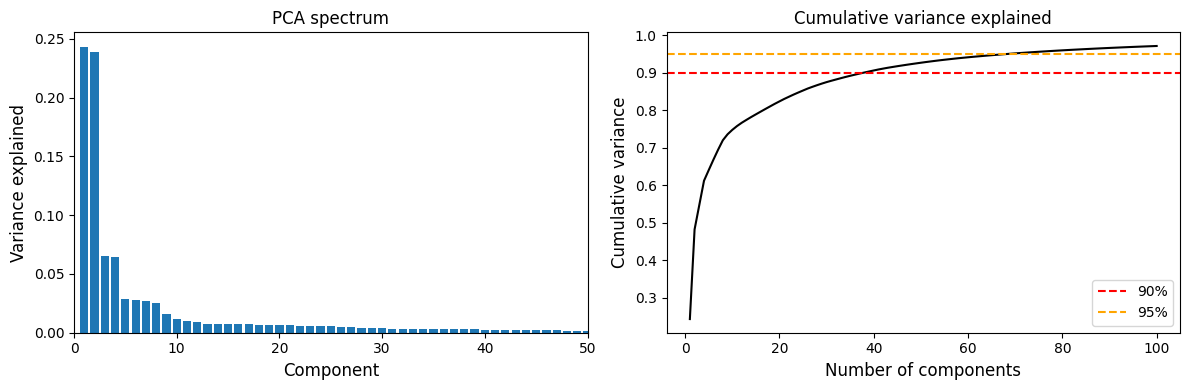

In [7]:
# Variance explained
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(range(1, n_components + 1), pca.explained_variance_ratio_)
axes[0].set_xlabel("Component", fontsize=fontsize)
axes[0].set_ylabel("Variance explained", fontsize=fontsize)
axes[0].set_title("PCA spectrum", fontsize=fontsize)
axes[0].tick_params(labelsize=fontsize - 2)
axes[0].set_xlim(0, 50)

axes[1].plot(range(1, n_components + 1), cumvar, "k-")
axes[1].axhline(0.90, color="r", linestyle="--", label="90%")
axes[1].axhline(0.95, color="orange", linestyle="--", label="95%")
axes[1].set_xlabel("Number of components", fontsize=fontsize)
axes[1].set_ylabel("Cumulative variance", fontsize=fontsize)
axes[1].set_title("Cumulative variance explained", fontsize=fontsize)
axes[1].tick_params(labelsize=fontsize - 2)
axes[1].legend(fontsize=fontsize - 2)

plt.tight_layout()
plt.show()

We see that the top $K = 38$ POD modes explain approximately 90\% of the variance in the system.
This is equivalent to the _time-averaged kinetic energy_ of the fluctuations of the fluid about its mean flow.

Next, we visualize the coefficients of the top $5$ POD modes over a $10$ unit time interval.

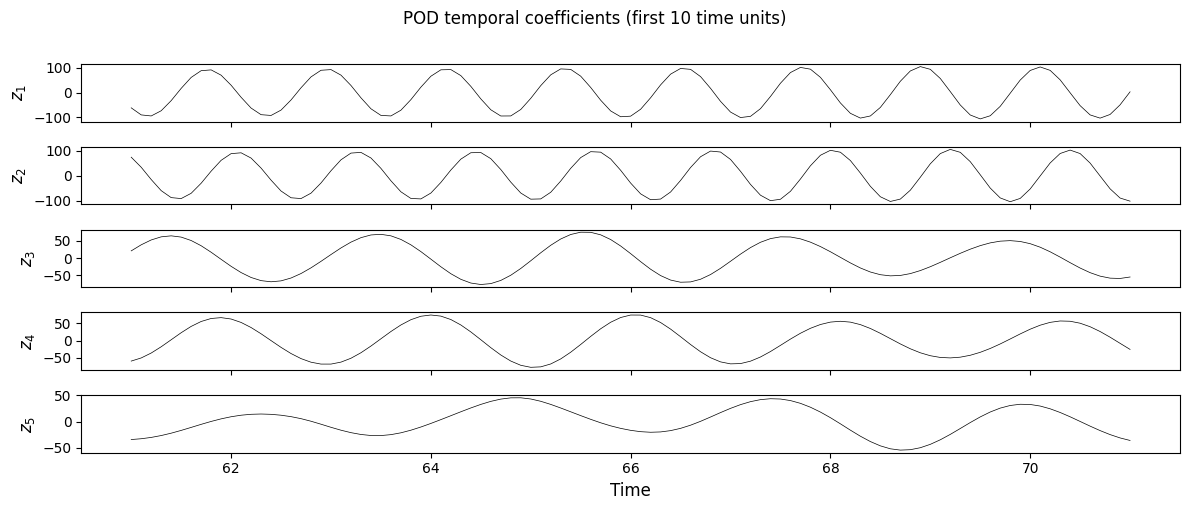

In [8]:
t_vis = 10 # time units to visualize

# Mask to first t_vis time units
vis_mask = t_all <= t_all[0] + t_vis

# Plot first few POD coefficients over time
n_show = min(n_90, 5)
fig, axes = plt.subplots(n_show, 1, figsize=(12, 1 * n_show), sharex=True)

for i in range(n_show):
    axes[i].plot(t_all[vis_mask], z_all[vis_mask, i], "k-", linewidth=0.5)
    if T_SPLIT <= t_all[vis_mask][-1]:
        axes[i].axvline(T_SPLIT, color="r", linestyle="--", linewidth=0.8, alpha=0.6)
    axes[i].set_ylabel(f"$z_{{{i+1}}}$", fontsize=fontsize)
    axes[i].tick_params(labelsize=fontsize - 2)

axes[-1].set_xlabel("Time", fontsize=fontsize)
fig.suptitle(f"POD temporal coefficients (first {t_vis} time units)", y=1.01, fontsize=fontsize)
plt.tight_layout()
plt.show()

We observe that the coefficients of the top POD modes are approximately periodic; this makes sense, since we excluded transients that arise from the initial condition. 
The coefficients possess varying frequencies.

Finally, we visualize the velocity field reconstructed from the top $K$ POD modes and their coefficients.

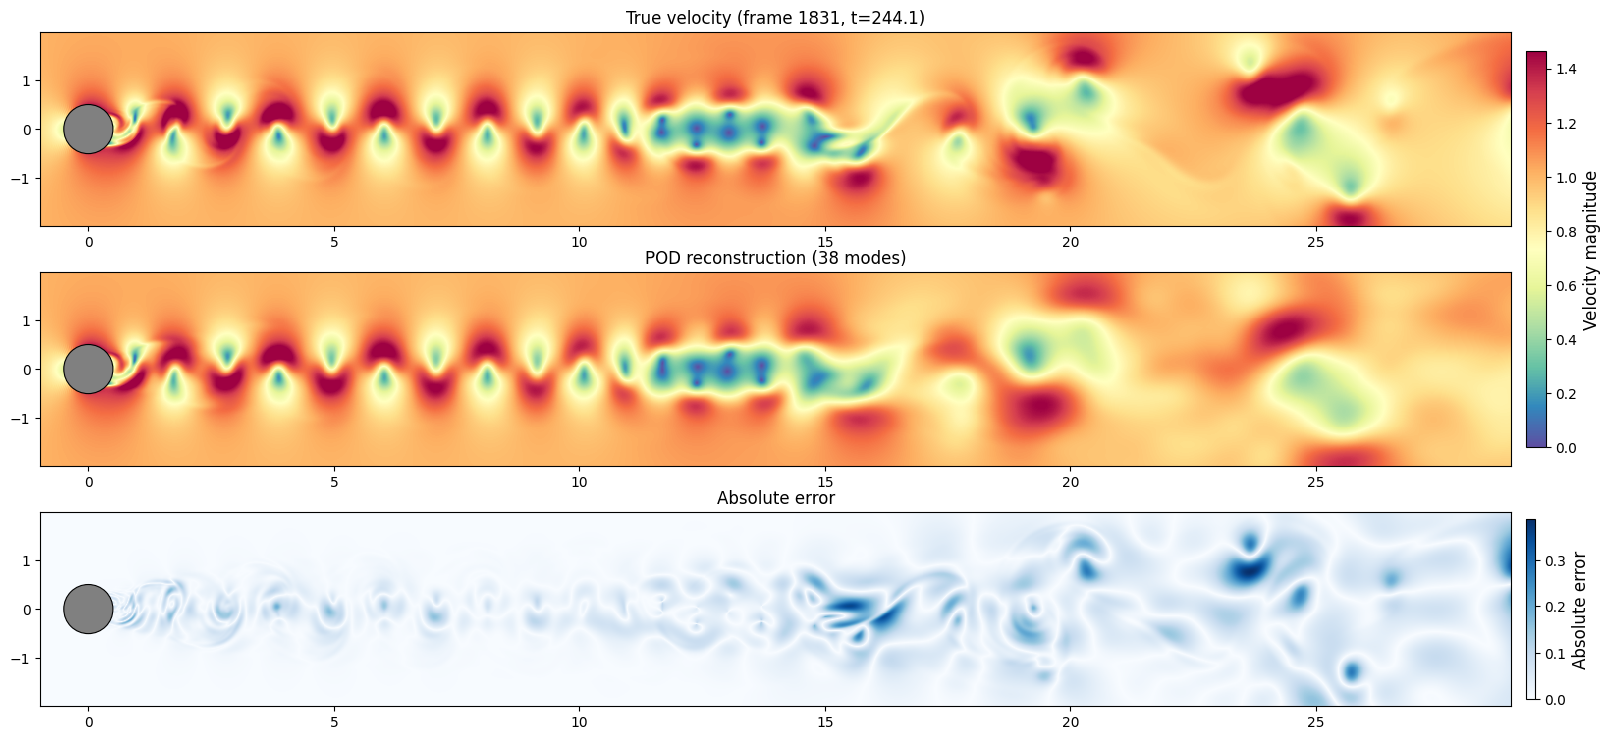

RMSE (full state, 38 modes): 0.058053


In [9]:
D = n_90
test_frame = n_post - n_post // 4
n_spatial = grid_shape[0] * grid_shape[1]
u_true, v_true = state_post[test_frame, :n_spatial].reshape(grid_shape), state_post[test_frame, n_spatial:].reshape(grid_shape)
u_recon, v_recon = decode_velocity(z_all[test_frame, :D], pca.components_[:D], pca.mean_, grid_shape, z_scale=1.0) # the POD coefficients are not rescaled yet
vel_true, vel_recon = np.sqrt(u_true ** 2 + v_true ** 2), np.sqrt(u_recon ** 2 + v_recon ** 2)

# Stacked panels: the true and reconstructed velocity magnitudes share the color limits and one colorbar, the error has its own
vel_lim = np.percentile(np.concatenate([vel_true.ravel(), vel_recon.ravel()]), 99)
fig, axes = plt.subplots(3, 1, figsize=(16, 2.4 * 3), constrained_layout=True)
im_vel = plot_field(vel_true, x_coord, y_coord, axes[0], vmin=0, vmax=vel_lim, title=f"True velocity (frame {test_frame}, t={t_all[test_frame]:.1f})", fontsize=fontsize)
plot_field(vel_recon, x_coord, y_coord, axes[1], vmin=0, vmax=vel_lim, title=f"POD reconstruction ({D} modes)", fontsize=fontsize)
im_err = plot_field(np.abs(vel_true - vel_recon), x_coord, y_coord, axes[2], cmap="Blues", vmin=0, title="Absolute error", fontsize=fontsize)
add_colorbar(fig, im_vel, axes[:2], "Velocity magnitude", fontsize)
add_colorbar(fig, im_err, axes[2:], "Absolute error", fontsize)
plt.show()

state_recon = np.concatenate([u_recon.ravel(), v_recon.ravel()])
print(f"RMSE (full state, {D} modes): {np.sqrt(np.mean((state_post[test_frame] - state_recon) ** 2)):.6f}")

The POD reconstruction of the velocity field closely resembles the true velocity field.

## Save processed data for training

In [10]:
D = n_90 # number of POD modes to retain

# Split POD codes into train/test
z_all_d = z_all[:, :D]
z_train_d = z_all_d[:n_train]
z_test_d = z_all_d[n_train:]

# Rescale POD codes: divide by max std across training modes
z_scale = z_train_d.std(axis=0).max()
z_train_scaled = z_train_d / z_scale
z_test_scaled = z_test_d / z_scale

print(f"Rescaling POD codes by z_scale = {z_scale:.4f}")
print(f"  Train: range [{z_train_scaled.min():.4f}, {z_train_scaled.max():.4f}]")
print(f"  Test:  range [{z_test_scaled.min():.4f}, {z_test_scaled.max():.4f}]")

processed = {
    "z_train": z_train_scaled.astype(np.float64), # (n_train, D)
    "t_train": t_train.astype(np.float64), # (n_train)
    "z_test": z_test_scaled.astype(np.float64), # (n_test, D)
    "t_test": t_test.astype(np.float64), # (n_test)
    "d": D,
    "z_scale": float(z_scale),
    "code_stdev": 1e-3, # observation noise std in rescaled space
    "pca_components": pca.components_[:D],
    "pca_mean": pca.mean_,
    "grid_shape": grid_shape,
    "x_coord": x_coord,
    "y_coord": y_coord,
}

SAVE_DIR = "../datasets/cylinder"
os.makedirs(SAVE_DIR, exist_ok=True)
with open(f"{SAVE_DIR}/encoded_data.pkl", "wb") as f:
    pickle.dump(processed, f)

print("\nSaved encoded_data.pkl")
print(f"  z_train: {processed['z_train'].shape}, t=[{t_train[0]:.1f}, {t_train[-1]:.1f}]")
print(f"  z_test:  {processed['z_test'].shape}, t=[{t_test[0]:.1f}, {t_test[-1]:.1f}]")
print(f"  d: {D} POD modes, z_scale: {z_scale:.4f}")

Rescaling POD codes by z_scale = 84.8508
  Train: range [-1.4807, 1.4789]
  Test:  range [-1.4666, 1.4693]

Saved encoded_data.pkl
  z_train: (1953, 38), t=[61.0, 256.2]
  z_test:  (488, 38), t=[256.3, 305.0]
  d: 38 POD modes, z_scale: 84.8508
